# Excitation Generation via Autoregressive Moving Average (ARMA)

Sampling i.i.d. noise (or a mixture of Gaussians) produces unstructured series: consecutive samples are independent, so there is no memory and no cycle. In [SymTime / $S^2$](https://arxiv.org/abs/2510.08445) we therefore also excite the symbolic generator with **stochastically parameterized ARMA processes**, which are the classical linear models of time-series analysis and already carry both randomness and serial dependence.

This mechanism first appeared as a stimulus prior in

> Wenxuan Wang, Kai Wu, Yujian Betterest Li, Dan Wang, Xiaoyu Zhang.<br>
> *Synthetic Series-Symbol Data Generation for Time Series Foundation Models*.<br>
> **NeurIPS 2025**. [arXiv:2510.08445](https://arxiv.org/abs/2510.08445)

`s2generator.excitation.AutoregressiveMovingAverage` is the object-oriented implementation used in that pipeline (and in this package). The notes below follow the updated generator: one IIR filter over a shared innovation path, AR coefficients built from characteristic roots, and an explicit `stationary` switch.

## The linear recurrence

An $\mathrm{ARMA}(p,q)$ path $\{x_t\}$ is driven by Gaussian innovations $\varepsilon_t \sim \mathcal{N}(0,1)$ through

$$
x_t
= \sum_{i=1}^{p} \varphi_i\, x_{t-i}
+ \varepsilon_t
+ \sum_{j=1}^{q} \theta_j\, \varepsilon_{t-j}.
$$

- The **AR** part $\varphi$ is a linear memory of past *outputs*. Complex-conjugate AR roots near the unit circle produce a slowly decaying oscillation (quasi-periodicity).
- The **MA** part $\theta$ is a linear memory of past *shocks*. A decaying MA kernel colours $\varepsilon_t$ toward lower frequencies so the AR cycle is not buried in white noise.

In the $z$-domain this is the rational filter $B(z)/A(z)$ with

$$
A(z)=1-\varphi_1 z^{-1}-\cdots-\varphi_p z^{-p},\qquad
B(z)=1+\theta_1 z^{-1}+\cdots+\theta_q z^{-q},
$$

which is why the implementation can generate a whole path with a single `scipy.signal.lfilter` call instead of a Python loop.

## Stationarity from the AR roots

The causal AR polynomial is (weakly) **stationary** if and only if every characteristic root satisfies $|r|<1$ (inside the unit disk). A pair of conjugate roots

$$
r e^{\pm i\omega}
\quad\Longrightarrow\quad
\varphi_1=2r\cos\omega,\;\varphi_2=-r^2
$$

has period $T=2\pi/\omega$ samples and damping $r^t$. The generator samples $T\in[8,48]$ so several cycles fit on a length-256/512 window, and:

| `stationary` | modulus of AR roots | typical look |
| --- | --- | --- |
| `True` (default) | $r\in[0.85,0.98]$ | persistent but mean-reverting cycles |
| `False` | $r\in[0.95,1.12]$ | near unit-root / mildly explosive wander |

A genuine oscillatory mode needs **$p\ge 2$** (one conjugate pair). The examples below therefore set `p_min=2`.

## ACF and PACF (what we will plot)

For a stationary ARMA process:

- **ACF** of a quasi-periodic AR(2) is a damped sinusoid at period $T$; a non-stationary / unit-root path has an ACF that barely decays.
- **PACF** of a pure AR($p$) cuts off after lag $p$; MA terms smear that cutoff, but a large lag-1 PACF plus a slow ACF is the usual non-stationary signature.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.excitation import AutoregressiveMovingAverage


def ar_roots(phi):
    """Roots of 1 - phi_1 z^{-1} - ... - phi_p z^{-p}."""
    phi = np.asarray(phi, dtype=float).reshape(-1)
    return np.roots(np.concatenate(([1.0], -phi)))


def plot_unit_disk(ax, roots, title):
    ax.add_patch(Circle((0, 0), 1.0, fill=False, color="0.35", lw=1.2))
    ax.axhline(0, color="0.75", lw=0.8)
    ax.axvline(0, color="0.75", lw=0.8)
    ax.scatter(np.real(roots), np.imag(roots), c="C3", s=42, zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


def plot_acf_pacf(series, title, lags=40):
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.1))
    axes[0].plot(series, color="royalblue", lw=1.1)
    axes[0].set_title(title)
    axes[0].set_xlabel("t")
    axes[0].grid(True, alpha=0.3)
    plot_acf(series, lags=lags, ax=axes[1], title="ACF")
    plot_pacf(series, lags=lags, ax=axes[2], title="PACF", method="ywm")
    fig.tight_layout()
    return fig


rng = np.random.RandomState(0)
print("AutoregressiveMovingAverage ready")

AutoregressiveMovingAverage ready


## Stationary generation (`stationary=True`)

With `p_min=2` every draw places at least one conjugate pair inside the unit disk. The paths should look like noisy cycles rather than white noise; the last realised `order` / `params` belong to the **last column** of a multivariate call.


shape: (512, 4)   last order: {'AR(p)': 2, 'MA(q)': 1}
AR phi: [ 1.789 -0.818]
MA theta: [-0.454]


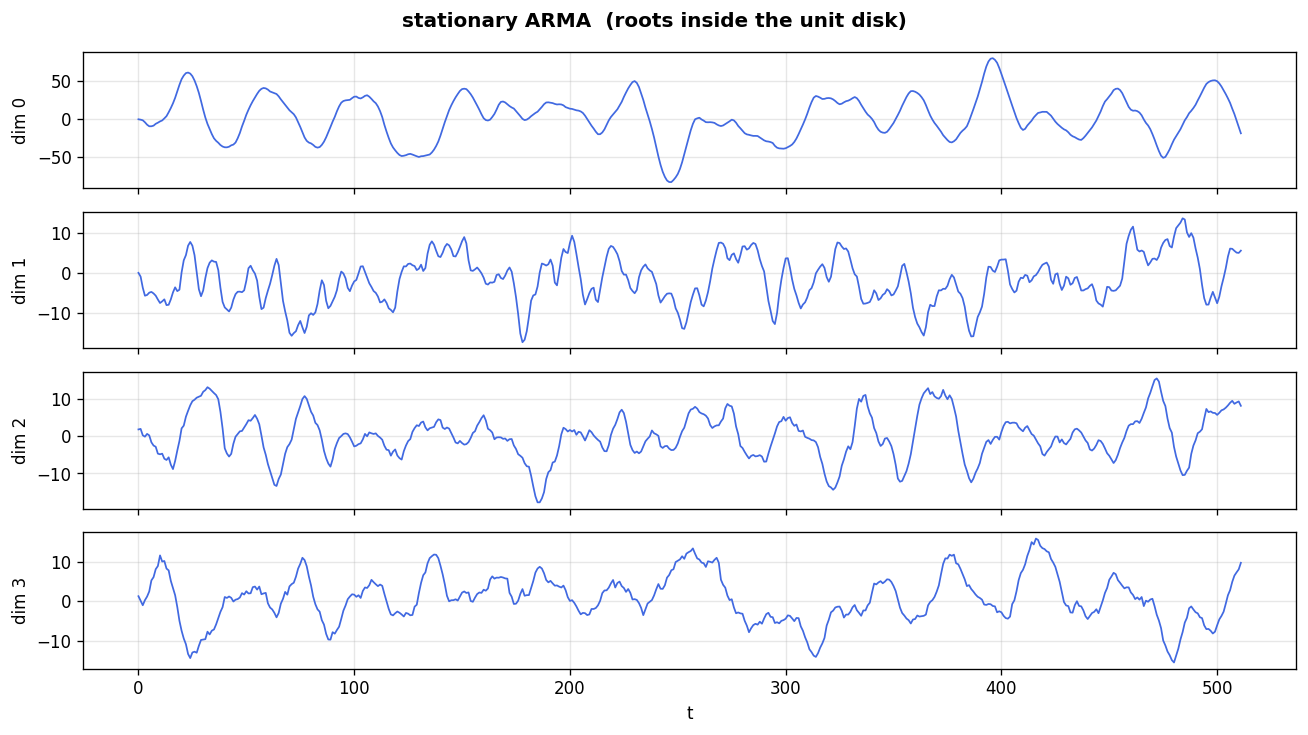

In [2]:
arma_s = AutoregressiveMovingAverage(
    p_min=2,
    p_max=5,
    q_min=1,
    q_max=4,
    stationary=True,
)

stat = arma_s.generate(
    rng=np.random.RandomState(0), n_inputs_points=512, input_dimension=4
)
print("shape:", stat.shape, "  last order:", arma_s.order)
print("AR phi:", np.round(arma_s.params["AR(p)"], 3))
print("MA theta:", np.round(arma_s.params["MA(q)"], 3))

fig, axes = plt.subplots(4, 1, figsize=(11, 6.2), sharex=True, dpi=120)
for i, ax in enumerate(axes):
    ax.plot(stat[:, i], color="royalblue", lw=1.05)
    ax.set_ylabel(f"dim {i}")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("t")
fig.suptitle("stationary ARMA  (roots inside the unit disk)", fontweight="bold")
fig.tight_layout()
plt.show()

## Constraint on the parameter draw: roots vs the unit circle

`create_autoregressive_params(..., stationary=True)` forces $|r|<1$; `stationary=False` is allowed to sit on or outside the circle. The scatter below is 12 independent AR(2) draws of each kind.


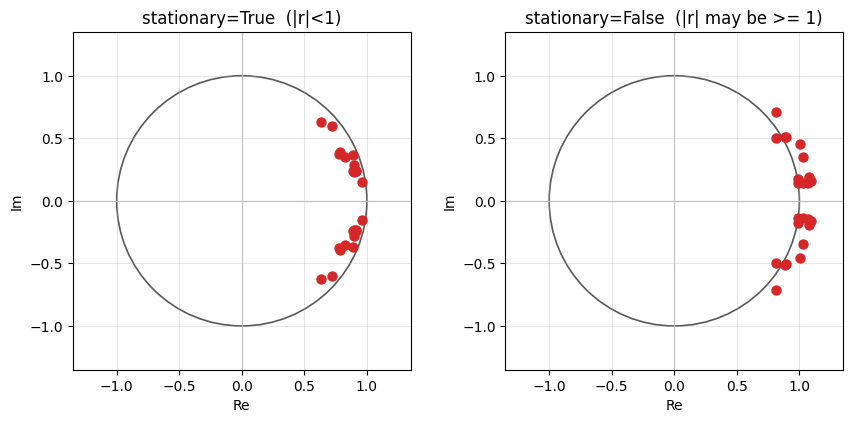

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.2))
rng_roots = np.random.RandomState(1)

for ax, flag, title in [
    (axes[0], True, "stationary=True  (|r|<1)"),
    (axes[1], False, "stationary=False  (|r| may be >= 1)"),
]:
    all_roots = []
    for _ in range(12):
        phi = AutoregressiveMovingAverage.create_autoregressive_params(
            rng_roots, p_order=2, stationary=flag
        )
        all_roots.append(ar_roots(phi))
    plot_unit_disk(ax, np.concatenate(all_roots), title)

fig.tight_layout()
plt.show()

## ACF / PACF of a stationary draw

Take one univariate stationary path. A damped-sinusoid ACF is the fingerprint of the conjugate AR pair; the PACF should be dominated by the first $p$ lags.


order: {'AR(p)': 2, 'MA(q)': 2}
AR roots |r| = [0.868 0.868]


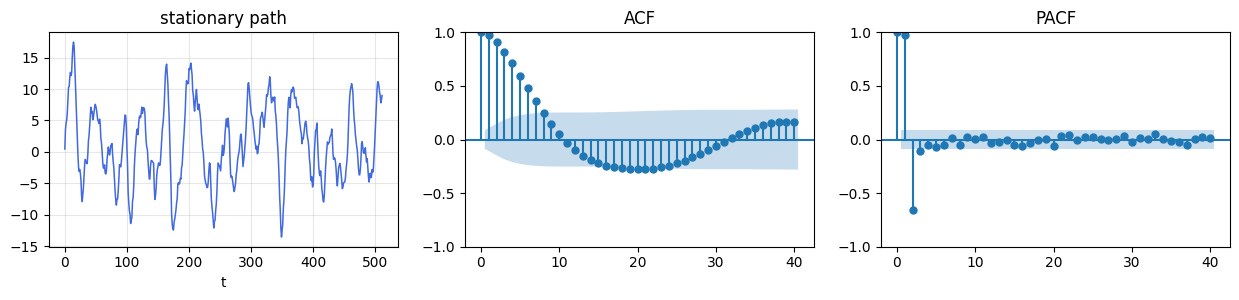

In [4]:
x_stat = arma_s.generate(
    rng=np.random.RandomState(4), n_inputs_points=512, input_dimension=1
)[:, 0]
print("order:", arma_s.order)
print("AR roots |r| =", np.round(np.abs(ar_roots(arma_s.params["AR(p)"])), 3))
plot_acf_pacf(x_stat, "stationary path")
plt.show()

## Non-stationary generation (`stationary=False`)

Turning the switch off lets AR moduli reach $[0.95, 1.12]$. Qualitatively:

- $|r|\approx 1$: the cycle (or the local level) barely damps — a stochastic trend / near unit root.
- $|r|>1$: the homogeneous solution *grows*; `generate` retries against `upper_bound` and clips if a draw still explodes, so the returned array stays finite.

The ACF of such a path decays very slowly (or not at all); the PACF typically shows a spike at lag 1.


shape: (512, 4)   last order: {'AR(p)': 2, 'MA(q)': 1}
AR roots |r| = [0.99 0.99]
peak |x| = 195.0766664336915


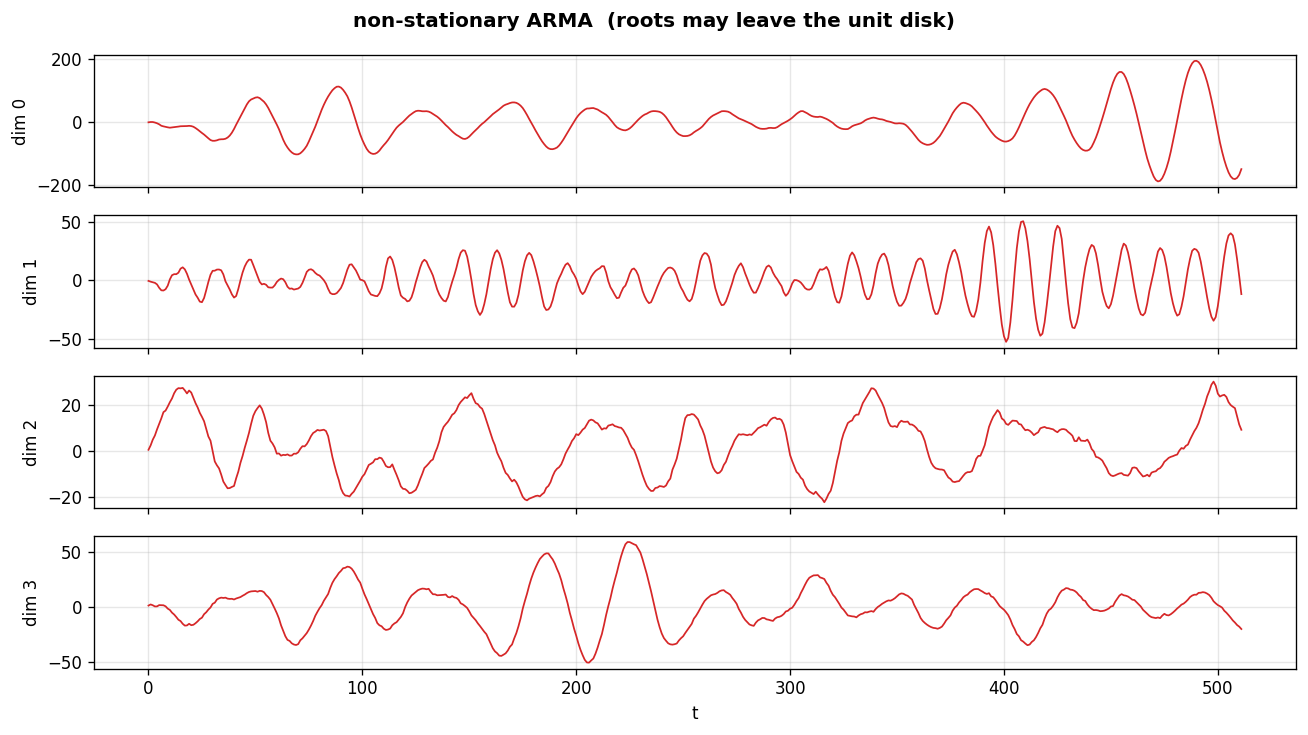

In [5]:
arma_n = AutoregressiveMovingAverage(
    p_min=2,
    p_max=5,
    q_min=1,
    q_max=3,
    stationary=False,
    upper_bound=256.0,
)

nonstat = arma_n.generate(
    rng=np.random.RandomState(8), n_inputs_points=512, input_dimension=4
)
print("shape:", nonstat.shape, "  last order:", arma_n.order)
print("AR roots |r| =", np.round(np.abs(ar_roots(arma_n.params["AR(p)"])), 3))
print("peak |x| =", float(np.max(np.abs(nonstat))))

fig, axes = plt.subplots(4, 1, figsize=(11, 6.2), sharex=True, dpi=120)
for i, ax in enumerate(axes):
    ax.plot(nonstat[:, i], color="C3", lw=1.05)
    ax.set_ylabel(f"dim {i}")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("t")
fig.suptitle("non-stationary ARMA  (roots may leave the unit disk)", fontweight="bold")
fig.tight_layout()
plt.show()

order: {'AR(p)': 2, 'MA(q)': 1}
AR roots |r| = [0.969 0.969]


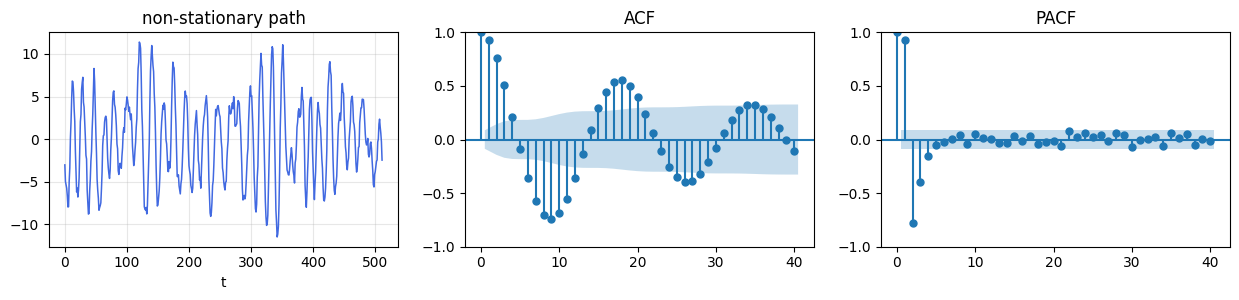

In [6]:
x_ns = arma_n.generate(
    rng=np.random.RandomState(11), n_inputs_points=512, input_dimension=1
)[:, 0]
print("order:", arma_n.order)
print("AR roots |r| =", np.round(np.abs(ar_roots(arma_n.params["AR(p)"])), 3))
plot_acf_pacf(x_ns, "non-stationary path")
plt.show()

## Manual coefficients

`create_autoregressive_params` / `create_moving_average_params` still expose a given order. Pass the vectors to `arma_series` to simulate one path on a zero buffer. Below: a hand-specified AR(2) pair with period $T=24$ and $r=0.96$, plus a random MA(3).


phi (period 24, r=0.96): [ 1.855 -0.922]
theta: [ 0.532 -0.344  0.223]
roots |r| = [0.96 0.96]


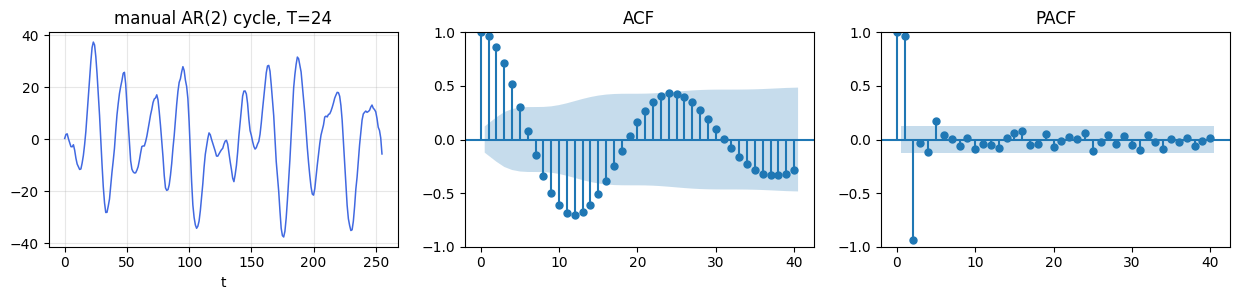

In [7]:
rng_m = np.random.RandomState(0)
period, rho = 24.0, 0.96
omega = 2.0 * np.pi / period
phi = np.array([2.0 * rho * np.cos(omega), -(rho**2)])
theta = arma_s.create_moving_average_params(rng_m, q_order=3)

x_manual = np.zeros(256)
x_manual = arma_s.arma_series(
    rng=rng_m, time_series=x_manual, p_params=phi, q_params=theta
)
print("phi (period 24, r=0.96):", np.round(phi, 3))
print("theta:", np.round(theta, 3))
print("roots |r| =", np.round(np.abs(ar_roots(phi)), 3))
plot_acf_pacf(x_manual, "manual AR(2) cycle, T=24")
plt.show()